In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# REPRODUCIBILITY

torch.manual_seed(0) 
np.random.seed(0)

# HYPERPARAMETERS

d = 10 # action space
c_penalty = 0.01 # action cost
initial_sigma = 0.1
min_sigma = 0.001
initial_policy_lr = 0.05  
min_policy_lr = 0.001
decay_power = 4.0
inner_steps = 15       
outer_steps = 4000
RM_lr = 0.001          
buffer_size = 50
FPO_weight = 0.005   

# true human utility function (Gaussian Peak on first 2 dimensions)
y_ideal = torch.zeros(d)
y_ideal[0] = 2.5
y_ideal[1] = 2.5

def true_utility(y, tau=0.2, A=10.0):
    dist_sq = torch.sum((y - y_ideal)**2, dim=-1)
    return A * torch.exp(-tau * dist_sq)

class NonlinearRM(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, 32),
            nn.Softplus(),
            nn.Linear(32, 32),
            nn.Softplus(),
            nn.Linear(32, 1)
        )

        with torch.no_grad():
            for m in self.net.modules():
                if isinstance(m, nn.Linear):
                    m.weight.normal_(0, 0.1)
                    m.bias.normal_(0, 0.0)

    def forward(self, x):
        return self.net(x).squeeze(-1)

def run_simulation(use_fpo=False):
    rm = NonlinearRM(d)
    optimizer_rm = optim.Adam(rm.parameters(), lr=RM_lr, weight_decay=1e-3)
    theta = torch.zeros(d, requires_grad=True)

    history = {'utility': [], 'traj': [], 'proxy': [], 'noise': []}
    buffer_y, buffer_u = [], []

    name = "FPO (Ours)" if use_fpo else "Standard RLHF"
    print(f"Running {name}...")

    for step in range(outer_steps):

        progress = step / float(outer_steps)
        decay_factor = 1.0 - (progress ** decay_power)

        current_sigma = min_sigma + (initial_sigma - min_sigma) * decay_factor
        current_policy_lr = min_policy_lr + (initial_policy_lr - min_policy_lr) * decay_factor

        # inner loop: policy optimization
        for _ in range(inner_steps):
            eps = torch.randn(d)
            y_s = theta + current_sigma * eps
            reward = rm(y_s)

            if use_fpo:
                params = list(rm.parameters())
                # 1. get gradients of the RM with respect to its own parameters
                grad_phi = torch.autograd.grad(reward, params, create_graph=True)
                
                # 2. gradient norm squared
                grad_norm_sq = sum(torch.sum(g**2) for g in grad_phi)
                u_true = true_utility(y_s).detach()

                # 3. error
                error = reward - u_true 
                # FOR PRACTICAL PENALTY UNCOMMENT:
                # error = 1

                # 4. FPO penalty
                penalty = FPO_weight * error * grad_norm_sq
            else:
                penalty = 0.0

            cost = c_penalty * torch.sum(y_s**2)
            obj = reward - cost - penalty

            loss_policy = -obj
            grad_theta = torch.autograd.grad(loss_policy, theta)[0]
            
            # standard optimization step clipping to prevent NaNs in PyTorch
            grad_theta = torch.clamp(grad_theta, -1.0, 1.0) 

            with torch.no_grad():
                theta.sub_(current_policy_lr * grad_theta)

        # LOGGING
        curr_mean = theta.detach().clone()
        history['traj'].append(curr_mean.numpy())
        history['utility'].append(true_utility(curr_mean).item())
        history['proxy'].append(rm(curr_mean).item())
        
        # track noise magnitude
        history['noise'].append(np.linalg.norm(curr_mean[2:].numpy()))

        # outer loop: RM retraining
        with torch.no_grad():
            y_new = theta + current_sigma * torch.randn(5, d)
            u_new = true_utility(y_new)
            for i in range(5):
                buffer_y.append(y_new[i])
                buffer_u.append(u_new[i])

        if len(buffer_y) > buffer_size:
            buffer_y, buffer_u = buffer_y[-buffer_size:], buffer_u[-buffer_size:]

        y_batch = torch.stack(buffer_y)
        u_batch = torch.stack(buffer_u)

        optimizer_rm.zero_grad()
        loss_rm = nn.MSELoss()(rm(y_batch), u_batch)
        loss_rm.backward()
        optimizer_rm.step()

    return history

# EXECUTION 
std_res = run_simulation(use_fpo=False)
ic_res = run_simulation(use_fpo=True)

print("Simulation complete!")

Running Standard RLHF...
Running FPO (Ours)...
Simulation complete!


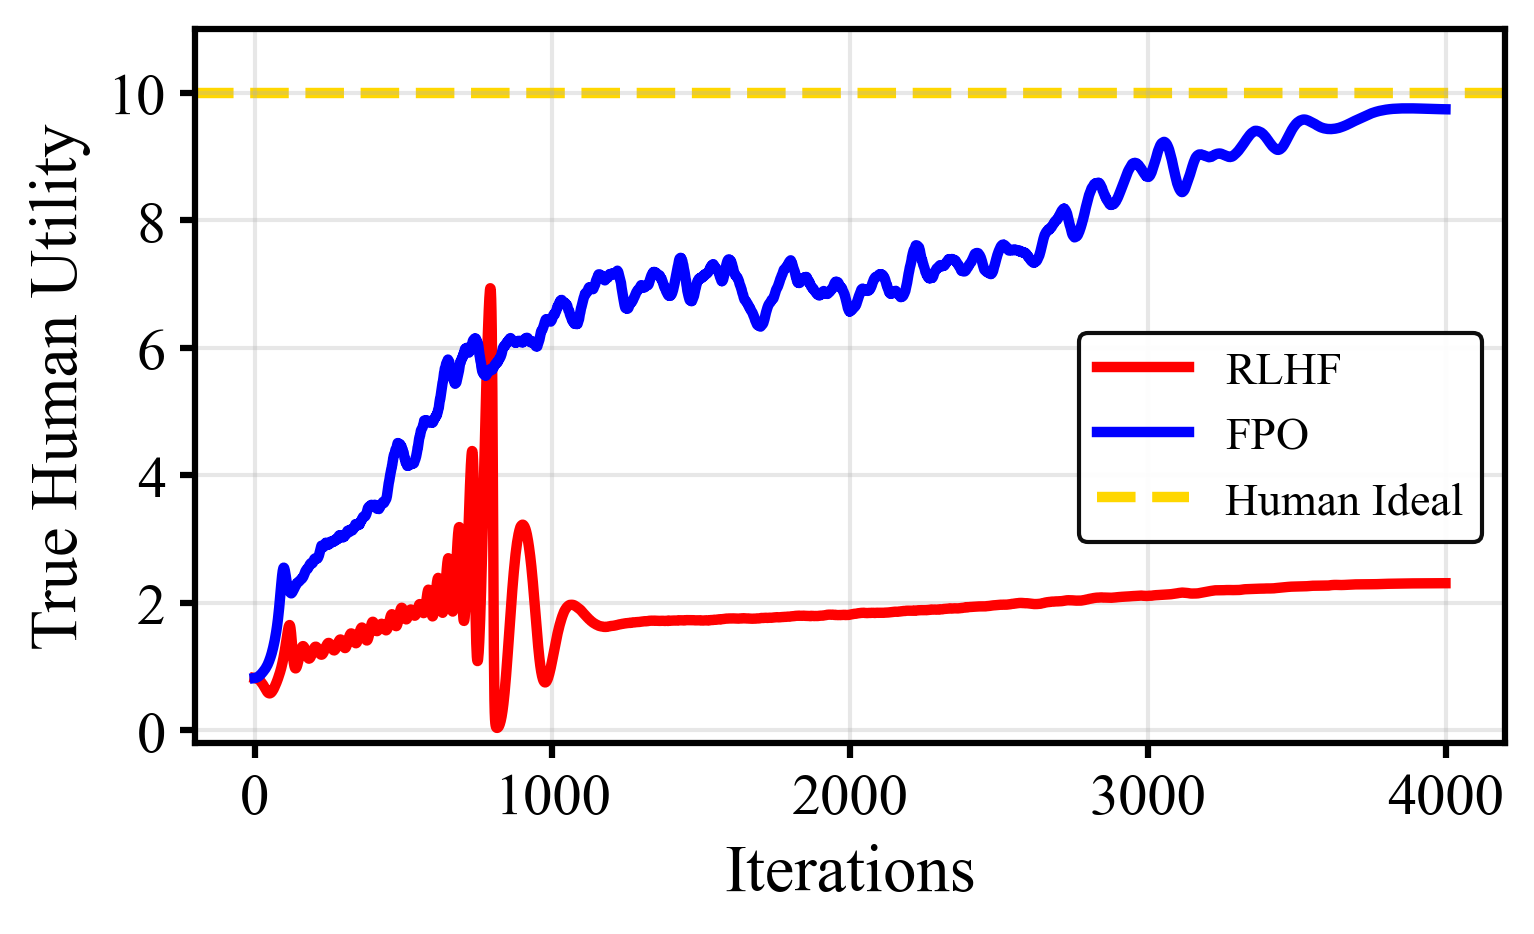

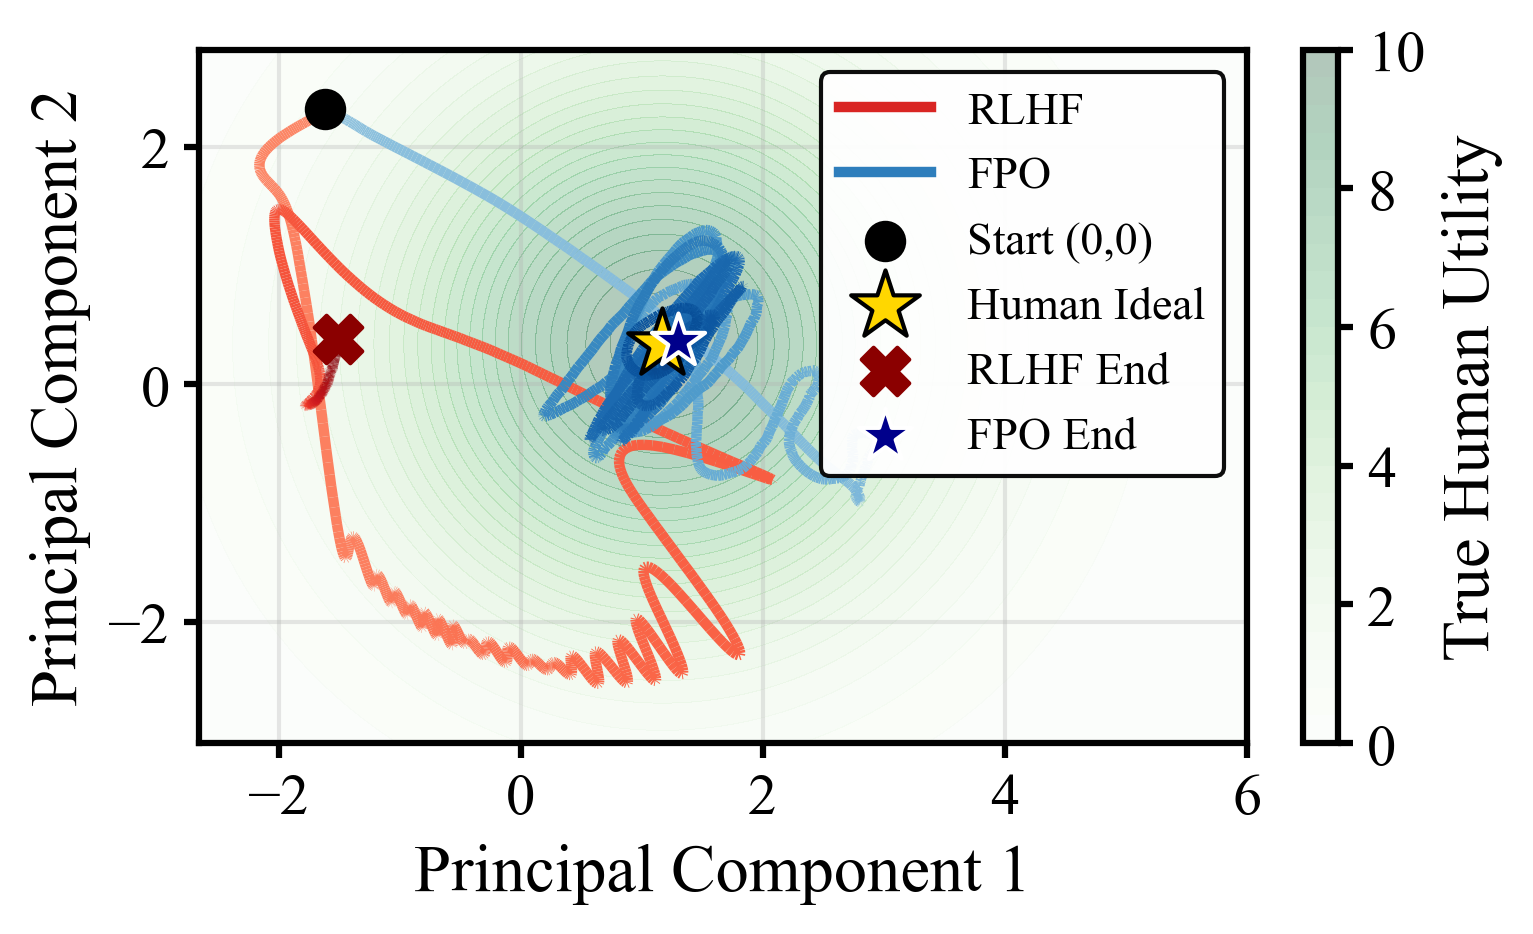

In [ ]:
from sklearn.decomposition import PCA
from matplotlib.collections import LineCollection

# PLOT STYLING 

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "axes.labelsize": 16,            
    "axes.titlesize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 11,           
    "lines.linewidth": 2.5,          
    "axes.linewidth": 1.5,           
    "xtick.major.width": 1.5,        
    "ytick.major.width": 1.5,
    "figure.figsize": (5, 3),    
    "figure.dpi": 300,
})

# DATA PREPARATION (PCA)

std_traj = np.array(std_res['traj'])
ic_traj = np.array(ic_res['traj'])
ideal_pt = y_ideal.numpy().reshape(1, -1)

# fit PCA
all_data = np.vstack([std_traj, ic_traj, ideal_pt, np.zeros((1, 10))]) # Assumes d=10
pca = PCA(n_components=2)
pca.fit(all_data)

std_pca = pca.transform(std_traj)
ic_pca = pca.transform(ic_traj)
ideal_pca = pca.transform(ideal_pt)

# PLOT 1: UTILITY DYNAMICS (Neural Network)

fig1, ax1 = plt.subplots(layout='constrained')

ax1.plot(std_res['utility'], color='red', linestyle='-', label='RLHF') 
ax1.plot(ic_res['utility'], color='blue', linestyle='-', label='FPO') 
ax1.axhline(10.0, color='gold', linestyle='--', label='Human Ideal', linewidth=2.5, zorder=1)

ax1.set_xlabel("Iterations")
ax1.set_ylabel("True Human Utility")
ax1.set_ylim(-0.2, 11)

ax1.legend(edgecolor='black', framealpha=0.95, loc='lower right', bbox_to_anchor=(1.0, 0.25))
ax1.grid(True, alpha=0.3, linewidth=1.0)

plt.show()

# PLOT 2: PCA TRAJECTORY PHASE SPACE

fig2, ax2 = plt.subplots(layout='constrained')

# set PCA limits safely
x_all = np.concatenate([std_pca[:,0], ic_pca[:,0], ideal_pca[:,0]])
y_all = np.concatenate([std_pca[:,1], ic_pca[:,1], ideal_pca[:,1]])
x_min, x_max = x_all.min() - 0.5, x_all.max() + 0.5
y_min, y_max = y_all.min() - 0.5, y_all.max() + 0.5

# Set PCA limits manually (to improve visual)
# x_min, x_max = -3, 6
# y_min, y_max = -3, 2
x_max = 6

ax2.set_xlim(x_min, x_max)
ax2.set_ylim(y_min, y_max)

# background utility contour mapped to PCA space
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 150), np.linspace(y_min, y_max, 150))
grid_pca = np.c_[xx.ravel(), yy.ravel()]
grid_10d = pca.inverse_transform(grid_pca) 

y_ideal_np = y_ideal.numpy()
def true_utility_np(y, tau=0.2, A=10.0):
    dist_sq = np.sum((y - y_ideal_np)**2, axis=-1)
    return A * np.exp(-tau * dist_sq)

Z_util = true_utility_np(grid_10d).reshape(xx.shape)
cs = ax2.contourf(xx, yy, Z_util, levels=25, cmap='Greens', alpha=0.3)

# add colorbar for the PCA plot
cbar = plt.colorbar(cs, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label('True Human Utility', size=plt.rcParams["axes.labelsize"])
cbar.ax.tick_params(labelsize=plt.rcParams["ytick.labelsize"])
cbar.set_ticks(np.linspace(0, 10, 6))

# helper to plot color-fading trajectories
def plot_pca_traj(ax, pca_data, cmap_name, label):
    points = pca_data.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    norm = plt.Normalize(-0.7 * len(pca_data), len(pca_data))
    lc = LineCollection(segments, cmap=cmap_name, norm=norm, linewidth=plt.rcParams["lines.linewidth"])
    lc.set_array(np.arange(len(pca_data)))
    ax.add_collection(lc)
    ax.plot([], [], color=plt.get_cmap(cmap_name)(0.7), label=label)

# plot trajectories
plot_pca_traj(ax2, std_pca, 'Reds', 'RLHF')
plot_pca_traj(ax2, ic_pca, 'Blues', 'FPO')

# plot markers
ax2.scatter([std_pca[0, 0]], [std_pca[0, 1]], c='black', s=80, label='Start (0,0)', zorder=10)
ax2.scatter([ideal_pca[0, 0]], [ideal_pca[0, 1]], marker='*', s=300, c='gold', edgecolors='black', label='Human Ideal', zorder=11)

# final points
ax2.scatter([std_pca[-1, 0]], [std_pca[-1, 1]], marker='X', s=130, c='darkred', zorder=12, label='RLHF End')
ax2.scatter([ic_pca[-1, 0]], [ic_pca[-1, 1]], marker='*', s=180, c='darkblue', zorder=13, edgecolors='white', label='FPO End')

ax2.set_xlabel("Principal Component 1")
ax2.set_ylabel("Principal Component 2")

ax2.legend(loc='upper right', edgecolor='black', framealpha=0.95)
ax2.grid(True, alpha=0.3, linewidth=1.0)

plt.show()

To generate multiple seed plots, iterate over seeds 0, 1, 2, 3, and 4.